# Phase 3: Post-Hoc Model Interpretability
This notebook opens the "black box" of our champion 145-feature LightGBM model. We will use **SHAP (Shapley Additive exPlanations)** and **Permutation Feature Importance** to explain both global model behavior and local individual predictions.

# Import the Libraries

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings('ignore')

WORKDIR = '/kaggle/working'
ARTIFACTS_DIR = '/kaggle/input/datasets/tahaarif23/sctp-artifacts'

# Loading Artifacts & Data

In [2]:
print("1. Loading Lean Model and Optimal 145 Features...")
try:
    lgb_model = joblib.load(os.path.join(ARTIFACTS_DIR, 'lightgbm_model_lean.pkl'))
    selected_features = joblib.load(os.path.join(ARTIFACTS_DIR, 'selected_features.pkl'))
    scaler = joblib.load(os.path.join(ARTIFACTS_DIR, 'scaler.joblib'))
    
    # Load raw validation data
    X_val = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_val.csv'))
    y_val = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_val.csv')).squeeze()
    
    print(f"Successfully loaded {len(selected_features)} optimal features and the champion model.")
except Exception as e:
    print(f"Error loading files. Check your directory paths: {e}")

1. Loading Lean Model and Optimal 145 Features...
Successfully loaded 145 optimal features and the champion model.


# Preprocessing & Subsampling

In [3]:
print("2. Preprocessing Data for SHAP...")

# Scale the entire validation set
X_val_scaled = scaler.transform(X_val)
feature_names_full = X_val.columns.tolist()

# Get indices of the selected features
selected_indices = [feature_names_full.index(feat) for feat in selected_features]

# Slice the scaled validation array to ONLY include the 145 selected features
X_val_lean = X_val_scaled[:, selected_indices]

# Take a random subset of 2000 rows for faster SHAP & Permutation calculation
# (Running these on all 40,000 rows takes hours and yields visually identical plots)
np.random.seed(42)
sample_indices = np.random.choice(X_val_lean.shape[0], size=2000, replace=False)
X_val_sample = X_val_lean[sample_indices]
y_val_sample = y_val.iloc[sample_indices]

print(f"Sampled {X_val_sample.shape[0]} customers for explainability analysis.")

2. Preprocessing Data for SHAP...
Sampled 2000 customers for explainability analysis.


# Calculating SHAP Values

In [4]:
print("3. Initializing SHAP TreeExplainer...")
# Using LightGBM's dedicated TreeExplainer for high-speed calculation
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_val_sample)

# Extract positive class SHAP values (target=1 : Transaction made)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print("SHAP values calculated successfully!")

3. Initializing SHAP TreeExplainer...
SHAP values calculated successfully!


# Global Explainability - SHAP Summary

Generating SHAP Beeswarm Plot (Global)...


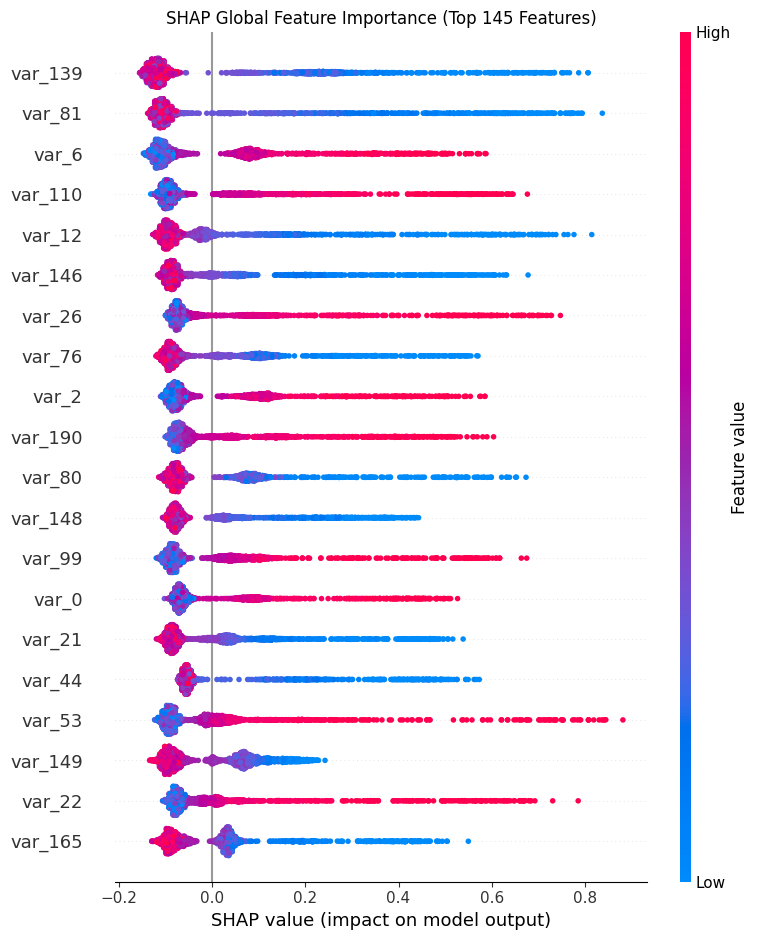

In [5]:
print("Generating SHAP Beeswarm Plot (Global)...")
plt.figure(figsize=(10, 8))
plt.title(f"SHAP Global Feature Importance (Top {len(selected_features)} Features)")
shap.summary_plot(shap_values_pos, X_val_sample, feature_names=selected_features, show=False)
plt.tight_layout()
plt.savefig(os.path.join(WORKDIR, 'shap_summary_plot.png'))
plt.show()

# Global Explainability - Permutation

Generating Permutation Importance (Second Interpretability Method)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

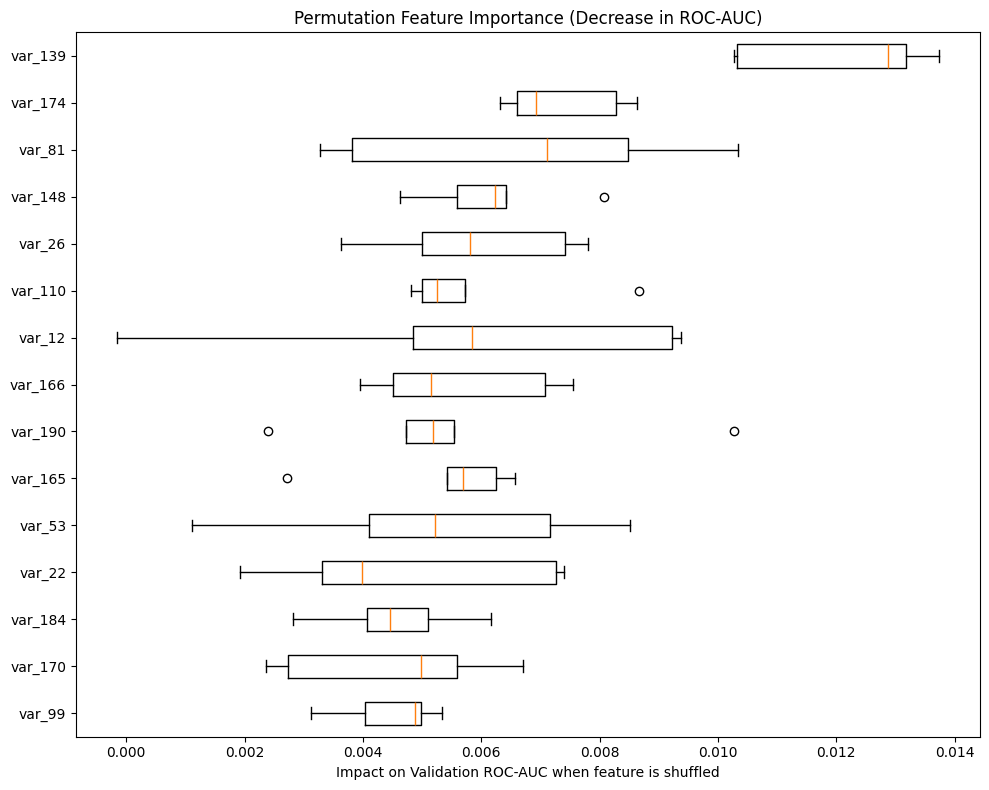

In [6]:
print("Generating Permutation Importance (Second Interpretability Method)...")
perm_importance = permutation_importance(
    lgb_model, X_val_sample, y_val_sample, n_repeats=5, random_state=42, n_jobs=-1, scoring='roc_auc'
)

# Get top 15 features by permutation importance
sorted_idx = perm_importance.importances_mean.argsort()[-15:]

plt.figure(figsize=(10, 8))
plt.boxplot(
    perm_importance.importances[sorted_idx].T,
    vert=False,
    labels=np.array(selected_features)[sorted_idx],
)
plt.title("Permutation Feature Importance (Decrease in ROC-AUC)")
plt.xlabel("Impact on Validation ROC-AUC when feature is shuffled")
plt.tight_layout()
plt.savefig(os.path.join(WORKDIR, 'permutation_importance.png'))
plt.show()

# Local Explainability - SHAP Waterfall

Generating Local Explanation for an Individual Customer...


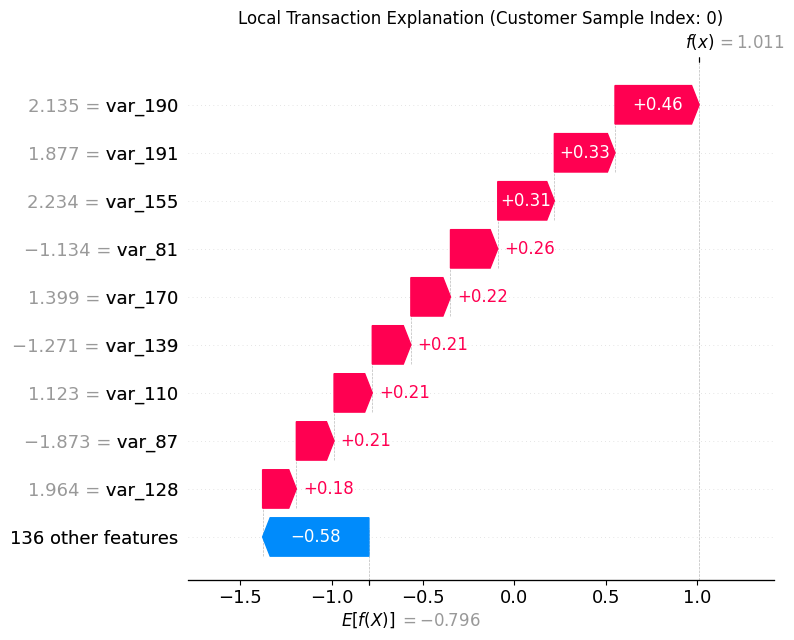


Phase 3 Complete! All interpretability plots saved to /kaggle/working.


In [7]:
print("Generating Local Explanation for an Individual Customer...")
# Explain the first customer in our subset (Change this index to look at different customers)
individual_idx = 0
individual_data = X_val_sample[individual_idx]

expected_value = explainer.expected_value
if isinstance(expected_value, list) or isinstance(expected_value, np.ndarray):
    expected_value = expected_value[1]

explanation = shap.Explanation(
    values=shap_values_pos[individual_idx],
    base_values=expected_value,
    data=individual_data,
    feature_names=selected_features
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title(f"Local Transaction Explanation (Customer Sample Index: {individual_idx})")
plt.tight_layout()
plt.savefig(os.path.join(WORKDIR, 'shap_local_waterfall.png'))
plt.show()

print("\nPhase 3 Complete! All interpretability plots saved to /kaggle/working.")

# Compliance Addendum: Multiple Local Explanations + Narrative
This section adds three local SHAP explanations and a structured global-vs-local discussion required by the brief.

In [ ]:
# Generate 3 local SHAP waterfall explanations
local_case_indices = [0, 1, 2]
for idx in local_case_indices:
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1]

    explanation = shap.Explanation(
        values=shap_values_pos[idx],
        base_values=expected_value,
        data=X_val_sample[idx],
        feature_names=selected_features
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, show=False)
    plt.title(f'Local SHAP Waterfall - Validation Sample {idx}')
    plt.tight_layout()
    plt.savefig(os.path.join(WORKDIR, f'shap_local_waterfall_{idx}.png'))
    plt.show()

## Global vs Local Discussion Notes (Use in Report)
- Global SHAP and permutation rankings identify consistently important features across the sample.
- Local waterfalls show case-specific shifts, where some globally important features may have weaker or opposite contribution for individual customers.
- Compare at least one case where local behavior aligns with global ranking and one case where it differs.
- Conclude how this improves trust and model interpretability for deployment.